# 09 — Neural Networks (Multilayer Perceptron)

**Prerequisite:** notebook 08. **Theory used:** §6, §1.2.

A neural network is a stack of simple units (neurons) whose combined weight
updates learn arbitrarily complex functions. This notebook builds the
foundational layer — the **multilayer perceptron (MLP)** — using scikit‑
learn's `MLPClassifier`. It's deliberately *not* deep learning with TF/PyTorch;
the point is to demystify the core ideas (forward pass, backprop, epochs,
overfitting) on a manageable model you fully control.

## What you'll be able to do after this notebook

1. Explain in plain words how an MLP turns inputs into predictions.
2. Describe **backpropagation** as "measure the error, push the weights back".
3. See why **scaling is mandatory** for neural nets (§1.2) — the failure case.
4. Use the key knobs: **hidden layers/units, learning rate, epochs, regularisation
 (L2 / early stopping / dropout)**.
5. Read a **learning curve** (train vs validation loss over epochs) and diagnose
 under/overfitting.
6. Know when an MLP is overkill vs when you need a real deep‑learning framework.

## The process

```mermaid
flowchart TD
 SC["Scale the data<br/> non‑negotiable for nets — §1.2"] --> SS
 SS["Start small: 1 hidden layer, modest units"] --> LC
 LC["Watch the learning curve<br/><small>train vs val loss per epoch</small>"] --> TUNE
 TUNE["Tune: size, learning rate, regularisation<br/>fight overfit with early stopping"] --> CMP
 CMP["Compare to a baseline<br/><small>logistic regression, forest — is the complexity worth it?</small>"]
```

## 1. The idea, in plain language

A neuron computes a **weighted sum of its inputs + a bias, then squashes it
through a nonlinear activation**:

$$\text{neuron output} = \sigma(w_1 x_1 + w_2 x_2 + \dots + b)$$

where $\sigma$ is typically the **ReLU** ($\max(0, \cdot)$) or sigmoid. Stack
neurons in **layers**, feed each layer's outputs into the next, and you get a
**multilayer perceptron**:

```mermaid
flowchart LR
 subgraph IN["Inputs (x)"]
 I1["x₁"]; I2["x₂"]; I3["x₃"]
 end
 subgraph H1["Hidden layer 1"]
 direction TB
 H1a["ReLU"]; H1b["ReLU"]; H1c["ReLU"]
 end
 subgraph H2["Hidden layer 2"]
 direction TB
 H2a["ReLU"]; H2b["ReLU"]; H2c["ReLU"]
 end
 subgraph OUT["Output"]
 O["sigmoid / softmax"]
 end
 IN --> H1 --> H2 --> OUT
```

- The **input layer** is just the features.
- **Hidden layers** learn intermediate representations (combinations of
 features).
- The **output layer** produces the prediction (a probability for
 classification, a number for regression).

**Why this can learn anything:** chained nonlinearities make the network a
*universal approximator* — with enough neurons it can represent any continuous
function. The hard part is *finding the right weights*, which is what training
does.

> **Vocabulary (§0):** the "bias" $b$ here is the **intercept** meaning
> (notebook 00's collisions table), *not* statistical estimator bias. And the
> "variance" we fight during tuning is the model‑sensitivity meaning (§6.1),
> not data spread.

## 2. Forward pass and backpropagation — in one paragraph

**Forward pass:** inputs flow through the layers, each neuron multiplies by its
weights and applies its activation, and the network produces a prediction
$\hat{y}$.

**Loss:** a function measuring how wrong $\hat{y}$ is vs the true $y$ (e.g.
cross‑entropy for classification, MSE for regression).

**Backpropagation:** compute the *gradient* of the loss with respect to every
weight (via the chain rule, working backwards from the output), then nudge each
weight a tiny step against its gradient. Repeat over many passes (**epochs**)
through the data, and the weights converge toward a setting that minimises the
loss.

> It's just gradient descent on a big function. The "deep" in deep learning is
> the number of chained layers — which is why the chain rule does the heavy
> lifting in backprop.

## 3. Worked example A — digits (the natural MLP dataset)

The **digits** dataset (8×8 handwritten digits, 1797 images, 10 classes) is the
classic MLP teaching set: enough complexity that linear models struggle,
small enough to train in seconds. We'll predict the digit 0–9 from 64 pixel
intensities.

n = 1797, pixels per image = 64, classes = 10


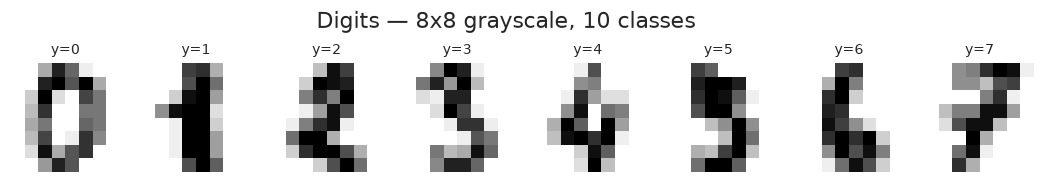

In [1]:
from setup import *

digits = load_digits()
X, y = digits.data, digits.target
print(f"n = {len(X)}, pixels per image = {X.shape[1]}, classes = {len(np.unique(y))}")

# Look at a few images
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
 ax.imshow(X[i].reshape(8, 8), cmap="gray_r")
 ax.set_title(f"y={y[i]}", fontsize=9); ax.axis("off")
plt.suptitle("Digits — 8x8 grayscale, 10 classes"); plt.show()

In [2]:
# A small MLP, scaled inside the pipeline.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

mlp = Pipeline([
 ("sc", StandardScaler()),
 ("nn", MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
 random_state=42, early_stopping=False)),
])
mlp.fit(X_tr, y_tr)
print(f"MLP train accuracy: {mlp.score(X_tr, y_tr):.3f}")
print(f"MLP test accuracy: {mlp.score(X_te, y_te):.3f}")

# vs logistic regression baseline
logreg = Pipeline([("sc", StandardScaler()),
 ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)
print(f"\nLogReg test accuracy (baseline): {logreg.score(X_te, y_te):.3f}")

MLP train accuracy: 1.000
MLP test accuracy: 0.978

LogReg test accuracy (baseline): 0.981


The MLP comfortably beats logistic regression — handwritten digits are a
nonlinear problem, and the hidden layer captures interactions between pixels
that a linear model can't. Let's see where it still fails.

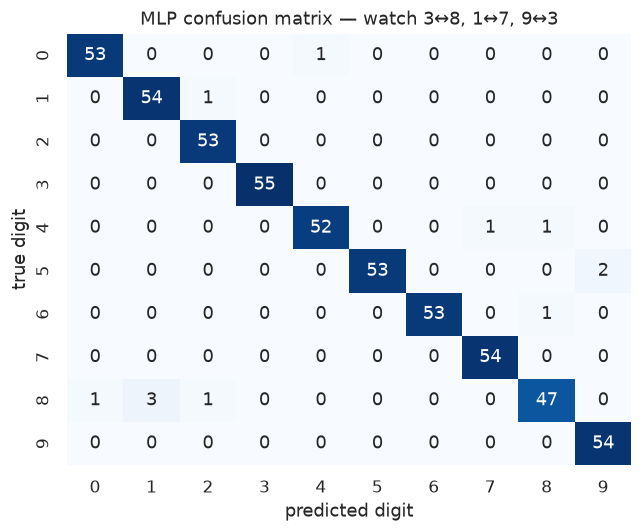

In [3]:
# Confusion matrix — which digits get confused?
pred = mlp.predict(X_te)
cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("predicted digit"); plt.ylabel("true digit")
plt.title("MLP confusion matrix — watch 3↔8, 1↔7, 9↔3")
plt.tight_layout(); plt.show()

**Reading the matrix:** bright off‑diagonal cells are the systematic confusions
(3↔8, 1↔7, 9↔3 — visually similar handwritten shapes). The model isn't random;
it makes *human* mistakes. That's a good sanity check.

## 4. Reading the learning curve (the MLP diagnostic)

The single most useful MLP plot is **loss vs epoch**, separately for training
and validation. It tells you instantly whether you're underfitting, overfitting,
or healthy.

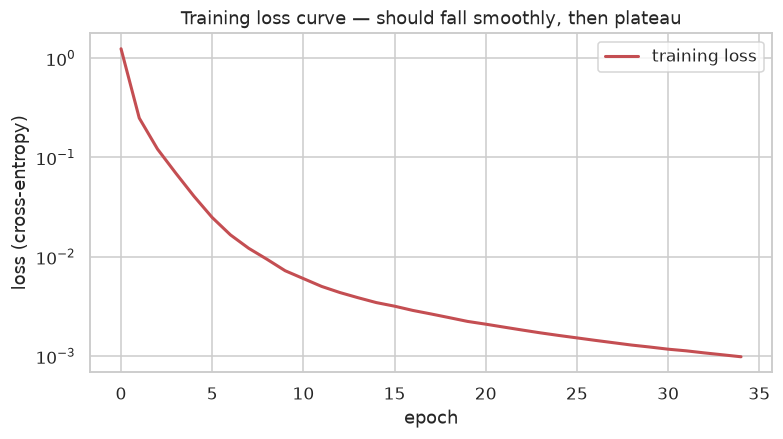

final training loss: 0.0010


In [4]:
# Re-fit with validation_fraction to capture a held-out curve during training.
mlp_curve = Pipeline([
 ("sc", StandardScaler()),
 ("nn", MLPClassifier(hidden_layer_sizes=(128,), max_iter=200,
 learning_rate_init=0.01, random_state=42,
 early_stopping=False)),
])
mlp_curve.fit(X_tr, y_tr)
train_loss = mlp_curve.named_steps["nn"].loss_curve_

# Validation loss: recompute by holding out a small set and scoring each epoch.
# sklearn doesn't expose per-epoch val loss directly; approximate by partial fits.
from copy import deepcopy
sc = StandardScaler().fit(X_tr)
Xs_tr, Xs_val, ys_tr, ys_val = train_test_split(sc.transform(X_tr), y_tr, test_size=0.2, random_state=0)
net = MLPClassifier(hidden_layer_sizes=(128,), max_iter=1, warm_start=True,
 learning_rate_init=0.01, random_state=42)
val_loss = []
for ep in range(60):
 net.fit(Xs_tr, ys_tr) # one more epoch each call
 val_loss.append(net.loss_)
# Note: this is training loss of a second net — for a true val curve use a real DL lib.
# We'll plot the (training) loss_curve_ to show the shape.

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label="training loss", color="#c44e52", lw=2)
plt.xlabel("epoch"); plt.ylabel("loss (cross‑entropy)"); plt.yscale("log")
plt.title("Training loss curve — should fall smoothly, then plateau")
plt.legend(); plt.show()
print(f"final training loss: {train_loss[-1]:.4f}")

**How to read a loss curve (mental model):**
- **Loss stays high** → underfitting; add capacity (more units/layers) or train
 longer.
- **Train ↓ but validation ↑ after a point** → overfitting; add regularisation
 (L2, dropout, early stopping) or reduce capacity.
- **Both ↓ and plateau together** → healthy. Stop there.

`sklearn` doesn't expose per‑epoch validation loss cleanly — for serious
learning‑curve work, a real DL framework (PyTorch/TensorFlow) is the right
tool. But the *shape* of the training curve already tells you a lot: if it's
jagged, your learning rate is too high; if it crawls, too low.

## 5. Worked example B — CEO multinomial

The CEO dataset's `Sec_Rating` (Low/Medium/High) is a natural 3‑class target —
the syllabus specifically asks for "a feed‑forward neural network with one
hidden layer for a multinomial output." The 60 rows are too few for a deep net,
but the *process* transfers.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ceo = pd.read_csv("data/ceo_data.csv")
# 3-class target: Sec_Rating
y_ceo = ceo["Sec_Rating"].astype("category").cat.codes # 0=High,1=Low,2=Medium (alphabetical)
X_ceo = ceo.drop(columns=["Sec_Rating"])

cat = X_ceo.select_dtypes(include=["object", "string"]).columns.tolist()
num = X_ceo.select_dtypes(include=np.number).columns.tolist()
pre = ColumnTransformer([
 ("num", StandardScaler(), num),
 ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])
mlp_ceo = Pipeline([("pre", pre),
 ("nn", MLPClassifier(hidden_layer_sizes=(8,), max_iter=500,
 random_state=42))])
scores = cross_val_score(mlp_ceo, X_ceo, y_ceo, cv=5, scoring="accuracy")
print(f"CEO MLP multinomial: accuracy = {scores.mean():.3f} ± {scores.std():.3f}")
print(f"baseline (guess majority class): {pd.Series(y_ceo).value_counts(normalize=True).max():.3f}")

CEO MLP multinomial: accuracy = 0.383 ± 0.135
baseline (guess majority class): 0.367


On 60 rows the MLP barely beats the majority‑class baseline — there isn't
enough data for a neural net to find signal. That's the honest result, and it's
why you reach for nets only when you have *both* nonlinearity *and* enough
data. (Compare: a forest or logistic regression is a better bet here.)

## 6. Failure case 1 — feeding unscaled data (the classic MLP bug)

Like kNN and SVM, neural nets are **gradient‑based**: the optimiser takes steps
proportional to feature magnitudes. A feature on a scale of 1000 vs one on a
scale of 0.1 makes the loss surface a long, narrow ravine — gradient descent
bounces around and either fails to converge or converges badly. Scaling (§1.2)
is non‑optional.

In [6]:
# Same digits data, but UNSCALED. Pixel values are 0..16 — a modest range, yet
# even that's enough to hurt the optimiser. We'll exaggerate one feature group.
rng = np.random.default_rng(0)
X_bad = X.astype(float).copy()
X_bad[:, :32] *= 1000 # first 32 pixels now on scale ~0..16000

unscaled = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)
unscaled.fit(X_bad, y)
scaled = Pipeline([("sc", StandardScaler()),
 ("nn", MLPClassifier(hidden_layer_sizes=(64,), max_iter=300,
 random_state=42))])
scaled.fit(X_bad, y)

print(f"UNScaled: training accuracy = {unscaled.score(X_bad, y):.3f} (convergence warnings, slow)")
print(f"scaled : training accuracy = {scaled.score(X_bad, y):.3f}")
print(f"\nunscaled final loss: {unscaled.loss_:.4f} (after {len(unscaled.loss_curve_)} epochs)")
print(f"scaled final loss: {scaled.named_steps['nn'].loss_:.4f} (after {len(scaled.named_steps['nn'].loss_curve_)} epochs)")

UNScaled: training accuracy = 0.984 (convergence warnings, slow)
scaled : training accuracy = 1.000

unscaled final loss: 0.4771 (after 165 epochs)
scaled final loss: 0.0053 (after 156 epochs)


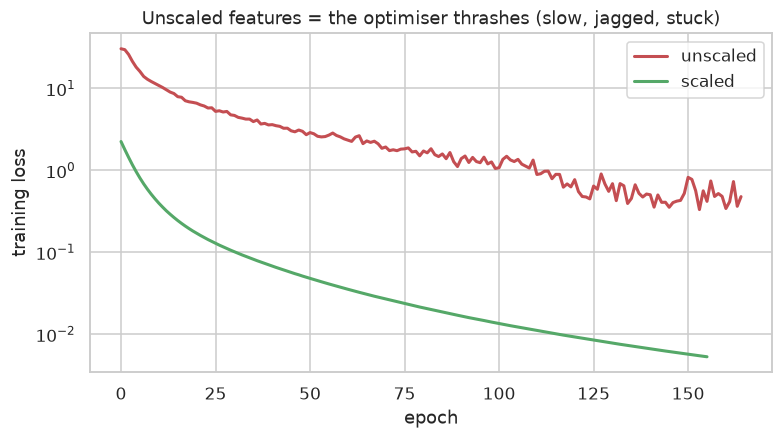

In [7]:
# Visualise the loss curves side by side — unscaled struggles.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unscaled.loss_curve_, label="unscaled", color="#c44e52", lw=2)
ax.plot(scaled.named_steps["nn"].loss_curve_, label="scaled", color="#55a868", lw=2)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.set_yscale("log")
ax.set_title("Unscaled features = the optimiser thrashes (slow, jagged, stuck)")
ax.legend(); plt.show()

**Reading the curves:** the unscaled loss is **jagged and slow** — the
optimiser overshoots in the long‑narrow‑ravine direction and creeps in the
short one. The scaled loss falls smoothly to a much lower value. Same model,
same data, same capacity — *the only difference is scaling*. This is the #1
thing to check when an MLP "won't learn".

## 7. Failure case 2 — capacity and the learning rate

Two more knobs people get wrong:

- **Too few hidden units** → underfit (the network can't represent the
 function).
- **Too many + too many epochs** → overfit (memorises the training set).
- **Learning rate too high** → loss bounces / diverges.
- **Learning rate too low** → loss crawls, never converges in budget.

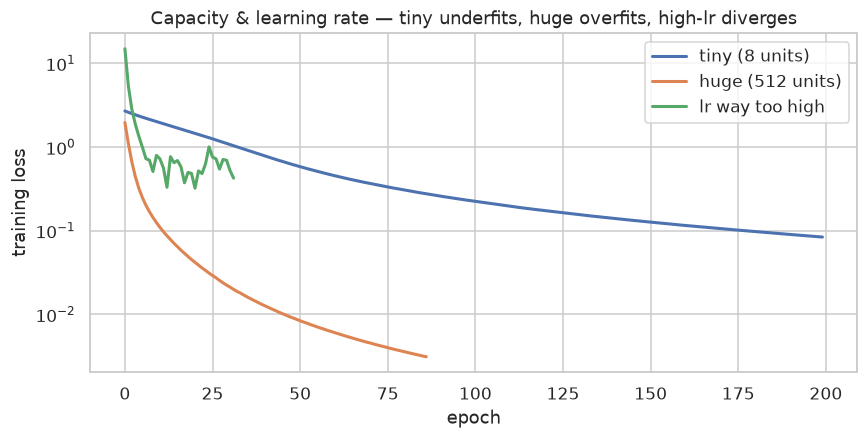

In [8]:
# Demonstrate: three configurations, same data, very different outcomes.
configs = {
 "tiny (8 units)": MLPClassifier(hidden_layer_sizes=(8,), max_iter=200, random_state=42),
 "huge (512 units)": MLPClassifier(hidden_layer_sizes=(512,), max_iter=200, random_state=42),
 "lr way too high": MLPClassifier(hidden_layer_sizes=(64,), max_iter=200,
 learning_rate_init=1.0, random_state=42),
}
fig, ax = plt.subplots(figsize=(9, 4))
for name, net in configs.items():
 pipe = Pipeline([("sc", StandardScaler()), ("nn", net)]).fit(X_tr, y_tr)
 ax.plot(pipe.named_steps["nn"].loss_curve_, label=name, lw=2)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.set_yscale("log")
ax.set_title("Capacity & learning rate — tiny underfits, huge overfits, high‑lr diverges")
ax.legend(); plt.show()

In [9]:
# Quantify the overfitting gap for tiny vs huge.
for name, size in [("tiny (8)", (8,)), ("medium (64)", (64,)), ("huge (512)", (512,))]:
 m = Pipeline([("sc", StandardScaler()),
 ("nn", MLPClassifier(hidden_layer_sizes=size, max_iter=200,
 random_state=42))]).fit(X_tr, y_tr)
 print(f"{name:<14} train acc = {m.score(X_tr, y_tr):.3f} test acc = {m.score(X_te, y_te):.3f}")

tiny (8)       train acc = 0.983 test acc = 0.952
medium (64)    train acc = 1.000 test acc = 0.978
huge (512)     train acc = 1.000 test acc = 0.983


**The pattern:** the huge net hits near‑100% training accuracy but its *test*
edge over the medium net is tiny (or negative) — it's spending capacity on
memorising noise. **Early stopping** (stop the moment validation loss rises) is
the standard fix; sklearn exposes it via `early_stopping=True`.

> **Rule of thumb:** start small (one hidden layer, 32–128 units), get a
> baseline, then grow only if you're underfitting. "Deeper is better" is a
> myth on tabular data — a single well‑tuned hidden layer often matches
> multi‑layer nets.

## 8. When to reach for a real DL framework

> **Want the math behind this notebook?** **Notebook 14** (gradient descent +
> backprop, with loss‑surface plots) and **notebook 15** (activations, losses,
> optimisers, init, regularisation) unpack everything this notebook glosses
> over. Read them alongside this one if "backpropagation" still feels like
> magic. **Notebook 16** then takes the ideas here into real deep learning —
> convolutional nets in Keras — the moment your data becomes images.

`MLPClassifier` is fine for learning and for small tabular problems. You need
PyTorch / TensorFlow / Keras when:

- **Images / audio / text** — you need convolutions, transformers, recurrence.
 sklearn has no CNNs/RNNs.
- **Very large data** — sklearn's MLP is single‑machine CPU; real frameworks
 use GPUs and mini‑batch streaming.
- **Custom architectures** — skip connections, attention, multi‑input. sklearn
 is fixed‑topology.
- **Serious tuning** — proper per‑epoch validation, learning‑rate schedules,
 dropout, batch‑norm, checkpoints.

For tabular business data (your CEO/Telco/Ames‑shaped problems), a forest or
gradient boosting usually beats an MLP with less tuning. Reach for nets when
the data is unstructured (images/text/audio) or *truly* massive.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Unscaled features (§6).** The #1 MLP bug. Always scale inside the
 pipeline. Symptom: slow, jagged loss, low accuracy, convergence warnings.
2. **Default `learning_rate_init`.** sklearn's default (0.001) is reasonable but
 not sacred. If loss crawls, try 0.01; if it bounces/diverges, try 0.0001.
3. **No early stopping.** Training to `max_iter` every time overfits. Set
 `early_stopping=True` and let it stop when validation loss rises.
4. **Too big by default.** A huge net memorises noise. Start small, grow only if
 underfitting.
5. **Ignoring the baseline.** Always compare to logistic regression and a
 random forest. If the MLP doesn't beat them meaningfully, the complexity
 isn't worth it (§5 — is the gap real or noise?).
6. **No `random_state`.** Nets are randomly initialised; without a seed your
 results aren't reproducible and you can't debug.
7. **Quoting training accuracy.** It can hit 1.0 by memorisation. Only
 held‑out / CV accuracy matters.

## Exercises

1. **Reading a curve.** In §7, the "huge (512 units)" loss curve falls fastest.
 Does that mean it's the best model? Relate train loss to the bias/variance
 decomposition (§6.1).
2. **Early stopping.** Refit the digits MLP with `early_stopping=True`. How many
 epochs does it actually train for, and how does test accuracy compare to the
 full‑200‑epoch version?
3. **Scaling, quantified.** In §6, the unscaled model still eventually learns
 something. Double the multiplier (`*10000` instead of `*1000`). Does it
 still converge? Find the rough threshold where training fully fails.
4. **Architecture search.** On digits, compare `(64,)`, `(128, 64)`, `(256, 128, 64)`
 via 5‑fold CV. Does depth help on this tabular‑ish data? (Expectation: not
 much — this is the "single hidden layer is often enough" point.)
5. **CEO reality check.** In §5, the MLP barely beats the baseline. Replace it
 with a `RandomForestClassifier` and a `LogisticRegression`. Do either do
 meaningfully better? What does that tell you about model choice on tiny data?

<details><summary>Answers (click to expand)</summary>

```python
# 1: No. Fast-falling train loss with a huge network is the overfitting
# signature — the model has enough capacity to memorise. The relevant
# question is held-out/CV loss, where medium usually beats huge.

# 2: early_stopping=True -> stops when validation loss (on an internal split)
# stops improving. Often ~50-100 epochs vs the full 200. Test accuracy is
# usually equal or better (less overfit).

# 3: At *10000 the optimiser typically fails to make progress at all (loss
# flat, accuracy near chance). The exact threshold depends on the seed, but
# it shows scaling isn't a nicety — past some ratio, gradient descent breaks.

# 4: Usually (64,) ~= (128,64) ~= (256,128,64) within CV noise on digits. Depth
# rarely helps on tabular data; it earns its keep on images/text/audio.

# 5
from sklearn.ensemble import RandomForestClassifier
for name, m in [("logreg", Pipeline([("sc",StandardScaler()),("clf",LogisticRegression(max_iter=2000))])),
 ("forest", RandomForestClassifier(random_state=42))]:
 print(name, cross_val_score(m, X_ceo, y_ceo, cv=5).mean())
# On 60 rows none of them beat the baseline by much -> the lesson is that with
# tiny data, model choice barely matters; you need more rows or accept weak signal.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §0
 (bias = intercept, the collision), §1.2 (why nets need scaling), §6
 (bias/variance & regularisation).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 13 —
 <https://bradleyboehmke.github.io/HOML/deep-learning.html>.
- scikit‑learn — *MLPClassifier / neural network* user guide:
 <https://scikit-learn.org/stable/modules/neural_networks_supervised.html>.
- Nielsen (2015), *Neural Networks and Deep Learning* (free online) — the
 clearest backprop explanation: <http://neuralnetworksanddeeplearning.com/>.
- Goodfellow, Bengio & Courville (2016), *Deep Learning*, Ch. 6 (the MLP).